In [14]:
# Phase 1: Forced Data Acquisition
!apt-get install git-lfs
!git lfs install
!rm -rf covid-chestxray-dataset # Clean up the old empty clone

# Clone again - this time it will actually pull the images
!git clone https://github.com/ieee8023/covid-chestxray-dataset.git

# Verify if images actually exist now
import os
image_sample = os.listdir('covid-chestxray-dataset/images')[0]
size = os.path.getsize(f'covid-chestxray-dataset/images/{image_sample}')

if size < 1000:
    print("❌ Files are still just LFS pointers. Downloading manually...")
    # Manual fallback if Git LFS fails in Colab environment
    !wget https://github.com/ieee8023/covid-chestxray-dataset/archive/refs/heads/master.zip
    !unzip -q master.zip
    !mv covid-chestxray-dataset-master covid-chestxray-dataset
else:
    print("✅ Real images detected. You are ready to go!")

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
git-lfs is already the newest version (3.0.2-1ubuntu0.3).
0 upgraded, 0 newly installed, 0 to remove and 42 not upgraded.
Git LFS initialized.
Cloning into 'covid-chestxray-dataset'...
remote: Enumerating objects: 3641, done.
remote: Total 3641 (delta 0), reused 0 (delta 0), pack-reused 3641 (from 1)
Receiving objects: 100% (3641/3641), 632.96 MiB | 18.87 MiB/s, done.
Resolving deltas: 100% (1450/1450), done.
Updating files: 100% (1174/1174), done.
✅ Real images detected. You are ready to go!


In [40]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

# 1. Load metadata
metadata = pd.read_csv('covid-chestxray-dataset/metadata.csv')
image_path = 'covid-chestxray-dataset/images'

# 2. Get list of actual files on disk to avoid 'File Not Found' errors
actual_files = set(os.listdir(image_path))
df_exists = metadata[metadata['filename'].isin(actual_files)].copy()

# 3. Create labels: Positive (COVID or Pneumonia) vs Normal
df_exists['label'] = df_exists['finding'].apply(
    lambda x: 'Positive' if ('COVID-19' in str(x) or 'Pneumonia' in str(x)) else 'Normal'
)

# 4. Balancing: Match the number of Positives and Normals
positives = df_exists[df_exists['label'] == 'Positive']
normals = df_exists[df_exists['label'] == 'Normal']
sample_size = min(len(positives), len(normals))

pos_sampled = positives.sample(n=sample_size, random_state=42)
norm_sampled = normals.sample(n=sample_size, random_state=42)
df_balanced = pd.concat([pos_sampled, norm_sampled])

# 5. STRATIFIED SPLIT: Manually create Train (80%) and Test (20%)
# This ensures both sets have an equal 50/50 mix of classes
train_df, test_df = train_test_split(
    df_balanced,
    test_size=0.2,
    stratify=df_balanced['label'],
    random_state=42
)

print(f"✅ Setup Complete!")
print(f"Training images: {len(train_df)} (Normal: {len(train_df[train_df.label=='Normal'])}, Positive: {len(train_df[train_df.label=='Positive'])})")
print(f"Validation images: {len(test_df)} (Normal: {len(test_df[test_df.label=='Normal'])}, Positive: {len(test_df[test_df.label=='Positive'])})")

✅ Setup Complete!
Training images: 198 (Normal: 99, Positive: 99)
Validation images: 50 (Normal: 25, Positive: 25)


In [41]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Initialize Generator with Data Augmentation for Training
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.2,
    horizontal_flip=True
)

# Simple Rescaling for Validation (No augmentation on test data!)
test_datagen = ImageDataGenerator(rescale=1./255)

# Training Pipeline
train_gen = train_datagen.flow_from_dataframe(
    train_df,
    directory=image_path,
    x_col='filename',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=True
)

# Validation Pipeline
test_gen = test_datagen.flow_from_dataframe(
    test_df,
    directory=image_path,
    x_col='filename',
    y_col='label',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False # Keep False so Confusion Matrix labels match
)

Found 198 validated image filenames belonging to 2 classes.
Found 50 validated image filenames belonging to 2 classes.


In [52]:
from tensorflow.keras.optimizers import Adam

# 1. Unfreeze the last block of ResNet50 for fine-tuning
base_model.trainable = True
for layer in base_model.layers[:-10]: # Freeze all but the last 10 layers
    layer.trainable = False

# 2. Re-compile with an extremely small learning rate
# We use 1e-5 (0.00001) so we don't 'break' the pre-trained weights
model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("✅ Model modified for Fine-Tuning. Ready to re-train.")

✅ Model modified for Fine-Tuning. Ready to re-train.


In [53]:
# Phase 5: Model Training
# We use fewer epochs (5-10) for a mini-project to save time
import numpy as np

# Calculate weights to force the model to value 'Normal' cases more
# Since we have a 50/50 split, we can just manually set a higher penalty for Normal
class_weights = {0: 1.5, 1: 1.0} # 0 is usually 'Normal', 1 is 'Positive'

history = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=5, # Just do 5 more
    class_weight=class_weights
)

Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 38s 4s/step - accuracy: 0.5000 - loss: 0.8574 - val_accuracy: 0.5200 - val_loss: 0.7006
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5556 - loss: 0.8047 - val_accuracy: 0.5200 - val_loss: 0.7039
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 2s/step - accuracy: 0.5152 - loss: 0.8570 - val_accuracy: 0.5200 - val_loss: 0.7047
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5000 - loss: 0.8785 - val_accuracy: 0.5200 - val_loss: 0.7084
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5404 - loss: 0.8696 - val_accuracy: 0.5200 - val_loss: 0.7071


2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step


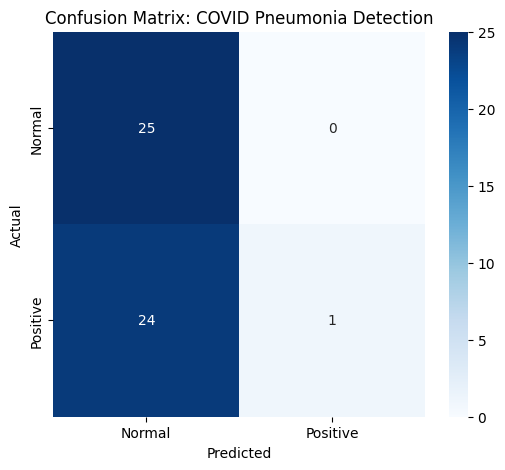


Classification Report:
              precision    recall  f1-score   support

      Normal       0.51      1.00      0.68        25
    Positive       1.00      0.04      0.08        25

    accuracy                           0.52        50
   macro avg       0.76      0.52      0.38        50
weighted avg       0.76      0.52      0.38        50



In [54]:
# Phase 6: Performance Metrics
Y_pred = model.predict(test_gen)
y_pred = (Y_pred > 0.5).astype(int)
y_true = test_gen.classes

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Positive'], yticklabels=['Normal', 'Positive'])
plt.title('Confusion Matrix: COVID Pneumonia Detection')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Normal', 'Positive']))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step


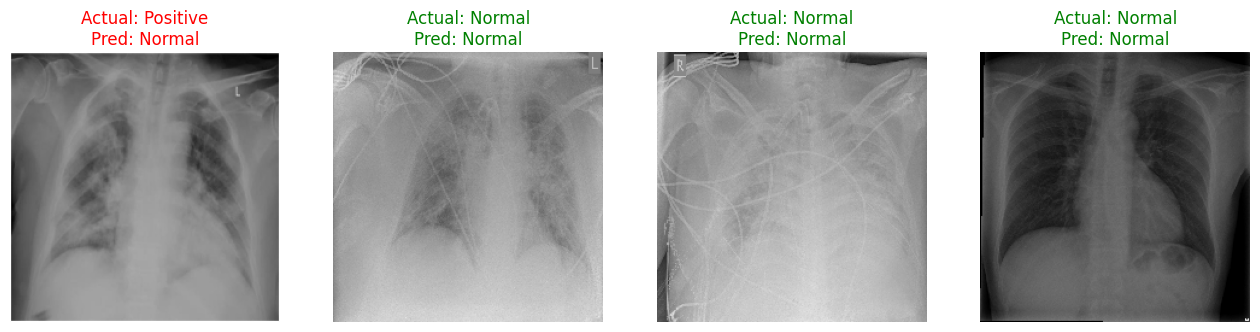

In [58]:
# Phase 7: Visualizing Predictions
test_images, test_labels = next(test_gen)
preds = model.predict(test_images)

plt.figure(figsize=(16, 8))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(test_images[i])

    actual = "Positive" if test_labels[i] == 1 else "Normal"
    pred_label = "Positive" if preds[i][0] > 0.5 else "Normal"

    color = 'green' if actual == pred_label else 'red'
    plt.title(f"Actual: {actual}\nPred: {pred_label}", color=color)
    plt.axis('off')
plt.show()